In [1]:
import sys
import os
from pathlib import Path
sys.path.append(os.path.join(os.getcwd(), "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", "..", "..", "..", ".."))
sys.path.append(os.path.join(os.getcwd(), "..", ".."))

In [29]:
import torch
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os
import pandas as pd
from torch.utils.data import DataLoader
import torch.nn.functional as F
import statistics
import math
import numpy as np
from torch.nn.functional import normalize
from src.models.baseline.nlp.transformer.transformer import TransformerEncoder
from src.models.haven.haven import HAVEN
from src.utils import constants, nn_utils, utils, dataset_utils
from src.datasets.protein_sequence_with_id_dataset import ProteinSequenceDatasetWithID
from src.datasets.collations.padding_with_id import PaddingWithID

In [30]:
input_file_path = os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/coronaviridae/20240313/sarscov2/sarscov2_variants_spike_seqences_ncbivirus_20250106_who_variants_downsampled.csv")
input_df = pd.read_csv(input_file_path, index_col=0)
input_df

,accession_id,species,genbank_or_refseq,pangolin_lineage,seq_length,protein,virus_host_name,geo_location,seq
0,YP_009724390.1,surface glycoprotein [Severe acute respiratory...,RefSeq,B,1273,surface glycoprotein,homo sapiens,China,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
0,QUR41397.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,Egypt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
1,UIX18801.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,USA: Illinois,MFVFLVLLPLVSSQCVXXTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
2,UFJ23379.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,USA: Florida,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
3,UGZ97974.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,USA: California,MFVFLVLLPLVSXXCVNLTTRTXXXPAYTNSFTRGVYYPDKVFRSS...
...,...,...,...,...,...,...,...,...,...
95,UNN31516.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1270,surface glycoprotein,homo sapiens,USA: Florida,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
96,WAA85805.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1272,surface glycoprotein,homo sapiens,USA,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
97,UIQ58390.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1270,surface glycoprotein,homo sapiens,USA: South Carolina,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...
98,WDU17786.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1270,surface glycoprotein,homo sapiens,Brazil,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...


In [4]:
input_df["pangolin_lineage"].unique()

array(['B', 'B.1.1.7', 'B.1.351', 'P.1', 'B.1.617.2', 'B.1.427',
       'B.1.429', 'P.2', 'B.1.525', 'P.3', 'B.1.526', 'B.1.617.1', 'C.37',
       'B.1.621', 'B.1.1.529', 'BA.1'], dtype=object)

In [5]:
who_designation_df = pd.read_csv(os.path.join(os.getcwd(), "..","..", "..", "..", "input/data/coronaviridae/20240313/sarscov2/sarscov2_who_designated_voc.csv"))
who_designation_df

,pango_lineage,who_variant,designation,first_designation_date,location
0,B,Wuhan-Hu-1,Index,12/01/2019,China
1,B.1.1.7,Alpha,VOC,12/08/2020,United Kingdom
2,B.1.351,Beta,VOC,12/18/2020,South Africa
3,P.1,Gamma,VOC,1/11/2021,Brazil
4,B.1.617.2,Delta,VOC,5/11/2021,India
5,B.1.427,Epsilon,VOI,3/5/2021,USA
6,B.1.429,Epsilon,VOI,3/5/2021,USA
7,P.2,Zeta,VOI,3/17/2021,Brazil
8,B.1.525,Eta,VOI,3/17/2021,Nigeria
9,P.3,Theta,VOI,3/24/2021,Philippines


In [6]:
who_designation_df["pango_who_annotation"] = who_designation_df["pango_lineage"] + " (" + who_designation_df["who_variant"] + ")" 
variant_order = who_designation_df["pango_who_annotation"].unique()
variant_order

array(['B (Wuhan-Hu-1)', 'B.1.1.7 (Alpha)', 'B.1.351 (Beta)',
       'P.1 (Gamma)', 'B.1.617.2 (Delta)', 'B.1.427 (Epsilon)',
       'B.1.429 (Epsilon)', 'P.2 (Zeta)', 'B.1.525 (Eta)', 'P.3 (Theta)',
       'B.1.526 (Iota)', 'B.1.617.1 (Kappa)', 'C.37 (Lambda)',
       'B.1.621 (Mu)', 'B.1.1.529 (Omicron)', 'BA.1 (Omicron)'],
      dtype=object)

In [7]:
who_designation_df.rename(columns={"pango_lineage": "pangolin_lineage"}, inplace=True)

In [8]:
input_df = pd.merge(input_df, who_designation_df, how="inner", on="pangolin_lineage")

In [9]:
input_df

,accession_id,species,genbank_or_refseq,pangolin_lineage,seq_length,protein,virus_host_name,geo_location,seq,who_variant,designation,first_designation_date,location,pango_who_annotation
0,YP_009724390.1,surface glycoprotein [Severe acute respiratory...,RefSeq,B,1273,surface glycoprotein,homo sapiens,China,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Wuhan-Hu-1,Index,12/01/2019,China,B (Wuhan-Hu-1)
1,QUR41397.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,Egypt,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Wuhan-Hu-1,Index,12/01/2019,China,B (Wuhan-Hu-1)
2,UIX18801.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,USA: Illinois,MFVFLVLLPLVSSQCVXXTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Wuhan-Hu-1,Index,12/01/2019,China,B (Wuhan-Hu-1)
3,UFJ23379.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,USA: Florida,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Wuhan-Hu-1,Index,12/01/2019,China,B (Wuhan-Hu-1)
4,UGZ97974.1,surface glycoprotein [Severe acute respiratory...,GenBank,B,1273,surface glycoprotein,homo sapiens,USA: California,MFVFLVLLPLVSXXCVNLTTRTXXXPAYTNSFTRGVYYPDKVFRSS...,Wuhan-Hu-1,Index,12/01/2019,China,B (Wuhan-Hu-1)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1521,UNN31516.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1270,surface glycoprotein,homo sapiens,USA: Florida,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Omicron,VOC,11/26/2021,South Africa,BA.1 (Omicron)
1522,WAA85805.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1272,surface glycoprotein,homo sapiens,USA,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Omicron,VOC,11/26/2021,South Africa,BA.1 (Omicron)
1523,UIQ58390.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1270,surface glycoprotein,homo sapiens,USA: South Carolina,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Omicron,VOC,11/26/2021,South Africa,BA.1 (Omicron)
1524,WDU17786.1,surface glycoprotein [Severe acute respiratory...,GenBank,BA.1,1270,surface glycoprotein,homo sapiens,Brazil,MFVFLVLLPLVSSQCVNLTTRTQLPPAYTNSFTRGVYYPDKVFRSS...,Omicron,VOC,11/26/2021,South Africa,BA.1 (Omicron)


In [14]:
input_df = input_df[input_df["accession_id"].isin(["YP_009724390.1", "UNN31516.1"])]

In [10]:
model_settings = {
    "name": "HAVEN",
    "model_path": os.path.join(os.getcwd(), "..","..", "..", "..", "output/raw/coronaviridae_s_prot_uniref90_embl_vertebrates_t0.01_c8/20240828/host_multi/fine_tuning_hybrid_cls/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_msl256b512_ae_bn_vs30cls_s64_hybrid_attention_s64_fnn_2l_d1024_lr1e-4_itr4.pth"),
    "segment_len": 256,
    "stride": 64,
    "cls_token": True,
    "n_heads": 8,
    "n_mlp_layers": 2,
    "n_classes": 8,
    "input_dim": 512, # input embedding dimension
    "hidden_dim": 1024,
    "data_parallel": False,
    "pre_train_settings": {
        "n_heads": 8,
        "depth": 6,
        "input_dim": 512, # input embedding dimension
        "hidden_dim": 1024,
        "max_seq_len": 256,
        "vocab_size": constants.VOCAB_SIZE
    }
}


label_settings = {
    "label_col": "virus_host_name",
    "exclude_labels": [ "nan"],
    "label_groupings": {
      "Chicken": [ "gallus gallus" ],
      "Human": [ "homo sapiens" ],
      "Cat": [ "felis catus" ],
      "Pig": [ "sus scrofa" ],
      "Gray wolf": [ "canis lupus" ],
      "Horseshoe bat": ["rhinolophus sp."],
      "Ferret": ["mustela putorius"],
      "Chinese rufous horseshoe bat": ["rhinolophus sinicus"]
    }
}


sequence_settings = {
    "batch_size": 2,
    "id_col": "accession_id",
    "sequence_col": "seq",
    "metadata_cols": ["pangolin_lineage", "geo_location", "seq_length"],
    "truncate": False,
    "split": False,
    "feature_type": "token",
    "max_sequence_length": 256
}

In [11]:
pre_trained_encoder_model = TransformerEncoder.get_transformer_encoder(model_settings["pre_train_settings"], model_settings["cls_token"])

TransformerEncoder(
  (embedding): EmbeddingLayer(
    (token_embedding): Embedding(30, 512)
    (positional_embedding): PositionalEncoding()
  )
  (encoder): Encoder(
    (layers): ModuleList(
      (0-5): 6 x EncoderLayer(
        (self_attn): MultiHeadAttention(
          (W_Q): Linear(in_features=512, out_features=512, bias=True)
          (W_K): Linear(in_features=512, out_features=512, bias=True)
          (W_V): Linear(in_features=512, out_features=512, bias=True)
          (W_O): Linear(in_features=512, out_features=512, bias=True)
        )
        (feed_forward): FeedForwardLayer(
          (W_1): Linear(in_features=512, out_features=1024, bias=True)
          (W_2): Linear(in_features=1024, out_features=512, bias=True)
        )
        (residual_connections): ModuleList(
          (0-1): 2 x ResidualConnectionLayer(
            (layer_norm): LayerNormalization()
          )
        )
      )
    )
    (layer_norm): LayerNormalization()
  )
)
Number of parameters =  12619776

In [12]:
model_settings["pre_trained_model"] = pre_trained_encoder_model
haven_model = HAVEN.get_model(model_params=model_settings)

HAVEN(
  (linear_ip): Linear(in_features=512, out_features=1024, bias=True)
  (linear_hidden): Linear(in_features=1024, out_features=1024, bias=True)
  (linear_hidden_n): ModuleList(
    (0-1): 2 x Linear(in_features=1024, out_features=1024, bias=True)
  )
  (linear_op): Linear(in_features=1024, out_features=8, bias=True)
  (batch_norm_ip): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm_hidden): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm_hidden_n): ModuleList(
    (0-1): 2 x BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pre_trained_model): TransformerEncoder(
    (embedding): EmbeddingLayer(
      (token_embedding): Embedding(30, 512)
      (positional_embedding): PositionalEncoding()
    )
    (encoder): Encoder(
      (layers): ModuleList(
        (0-5): 6 x EncoderLayer(
          (self_attn): MultiHeadAttention(
            (W_Q): Linear(i

In [13]:
haven_model.load_state_dict(torch.load(model_settings["model_path"], map_location=nn_utils.get_device()))

<All keys matched successfully>

In [16]:
df, index_label_map = utils.transform_labels(input_df, label_settings,
                                                     classification_type="mutli", silent=False)

Grouping labels using config : {'Chicken': ['gallus gallus'], 'Human': ['homo sapiens'], 'Cat': ['felis catus'], 'Pig': ['sus scrofa'], 'Gray wolf': ['canis lupus'], 'Horseshoe bat': ['rhinolophus sp.'], 'Ferret': ['mustela putorius'], 'Chinese rufous horseshoe bat': ['rhinolophus sinicus']}
label_idx_map={'Cat': 0, 'Chicken': 1, 'Chinese rufous horseshoe bat': 2, 'Ferret': 3, 'Gray wolf': 4, 'Horseshoe bat': 5, 'Human': 6, 'Pig': 7}
idx_label_map={0: 'Cat', 1: 'Chicken', 2: 'Chinese rufous horseshoe bat', 3: 'Ferret', 4: 'Gray wolf', 5: 'Horseshoe bat', 6: 'Human', 7: 'Pig'}


/home/blessyantony/dev/git/HAVEN/src/jupyter_notebooks/interpretability/attention_values/../../../../src/utils/utils.py:48: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[label_col] = df[label_col].transform(lambda x: label_idx_map[x] if x in label_idx_map else 0)


In [17]:
sequence_settings["max_sequence_length"]=1281
dataset_loader = dataset_utils.get_dataset_loader(df, sequence_settings, label_col=label_settings["label_col"], include_id_col=True)

>><<
1281


In [18]:
haven_model.eval()

HAVEN(
  (linear_ip): Linear(in_features=512, out_features=1024, bias=True)
  (linear_hidden): Linear(in_features=1024, out_features=1024, bias=True)
  (linear_hidden_n): ModuleList(
    (0-1): 2 x Linear(in_features=1024, out_features=1024, bias=True)
  )
  (linear_op): Linear(in_features=1024, out_features=8, bias=True)
  (batch_norm_ip): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm_hidden): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (batch_norm_hidden_n): ModuleList(
    (0-1): 2 x BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (pre_trained_model): TransformerEncoder(
    (embedding): EmbeddingLayer(
      (token_embedding): Embedding(30, 512)
      (positional_embedding): PositionalEncoding()
    )
    (encoder): Encoder(
      (layers): ModuleList(
        (0-5): 6 x EncoderLayer(
          (self_attn): MultiHeadAttention(
            (W_Q): Linear(i

In [19]:
seq_id, seq, label = next(iter(dataset_loader))

>>>
1281


In [20]:
print(f"seq_id = {seq_id}")
print(f"seq = {seq}, seq_len = {seq.shape}")
print(f"label = {label}")

seq_id = ('UNN31516.1', 'YP_009724390.1')
seq = tensor([[13., 14., 22.,  ...,  0.,  0.,  0.],
        [13., 14., 22.,  ...,  0.,  0.,  0.]], device='cuda:0',
       dtype=torch.float64), seq_len = torch.Size([2, 1281])
label = tensor([6, 6], device='cuda:0')


In [21]:
x = seq.unfold(dimension=1, size=256, step=64)
x.shape

torch.Size([2, 17, 256])

In [22]:
output = haven_model(seq)

Before = torch.Size([2, 1281])
After = torch.Size([2, 17, 256])


In [23]:
output.shape

torch.Size([2, 8])

In [24]:
output_prob = F.softmax(output, dim=-1)
result_df = pd.DataFrame(output_prob.detach().cpu().numpy())
result_df["id"] = seq_id
result_df["y_true"] = label.detach().cpu().numpy()
idx_label_map={0: 'Cat', 1: 'Chicken', 2: 'Chinese rufous horseshoe bat', 3: 'Ferret', 4: 'Gray wolf', 5: 'Horseshoe bat', 6: 'Human', 7: 'Pig'}
result_df.rename(columns=idx_label_map)

,Cat,Chicken,Chinese rufous horseshoe bat,Ferret,Gray wolf,Horseshoe bat,Human,Pig,id,y_true
0,0.045553,0.00002,0.542599,0.022297,0.004483,0.091929,0.279827,0.013292,UNN31516.1,6
1,0.022578,0.00001,0.101053,0.019672,0.005205,0.041709,0.786229,0.023544,YP_009724390.1,6


In [25]:
seq_len = seq.shape[1]
pos_mapping_range = {}
pos_mapping = {}
j = 0
for i in range(0, seq_len + 1, 64):
    start = i
    end = i + 256
    if end >= seq_len:
        break
    pos_mapping[j] = f"{j}: {start + 1}-{end}"
    pos_mapping_range[j] = [start, end]
    j += 1
    
pos_mapping

{0: '0: 1-256',
 1: '1: 65-320',
 2: '2: 129-384',
 3: '3: 193-448',
 4: '4: 257-512',
 5: '5: 321-576',
 6: '6: 385-640',
 7: '7: 449-704',
 8: '8: 513-768',
 9: '9: 577-832',
 10: '10: 641-896',
 11: '11: 705-960',
 12: '12: 769-1024',
 13: '13: 833-1088',
 14: '14: 897-1152',
 15: '15: 961-1216',
 16: '16: 1025-1280'}

In [26]:
pos_mapping_range

{0: [0, 256],
 1: [64, 320],
 2: [128, 384],
 3: [192, 448],
 4: [256, 512],
 5: [320, 576],
 6: [384, 640],
 7: [448, 704],
 8: [512, 768],
 9: [576, 832],
 10: [640, 896],
 11: [704, 960],
 12: [768, 1024],
 13: [832, 1088],
 14: [896, 1152],
 15: [960, 1216],
 16: [1024, 1280]}

In [27]:
idx=1
attn = haven_model.self_attn.self_attn[idx, :, :, :]
attn.shape

torch.Size([8, 17, 17])

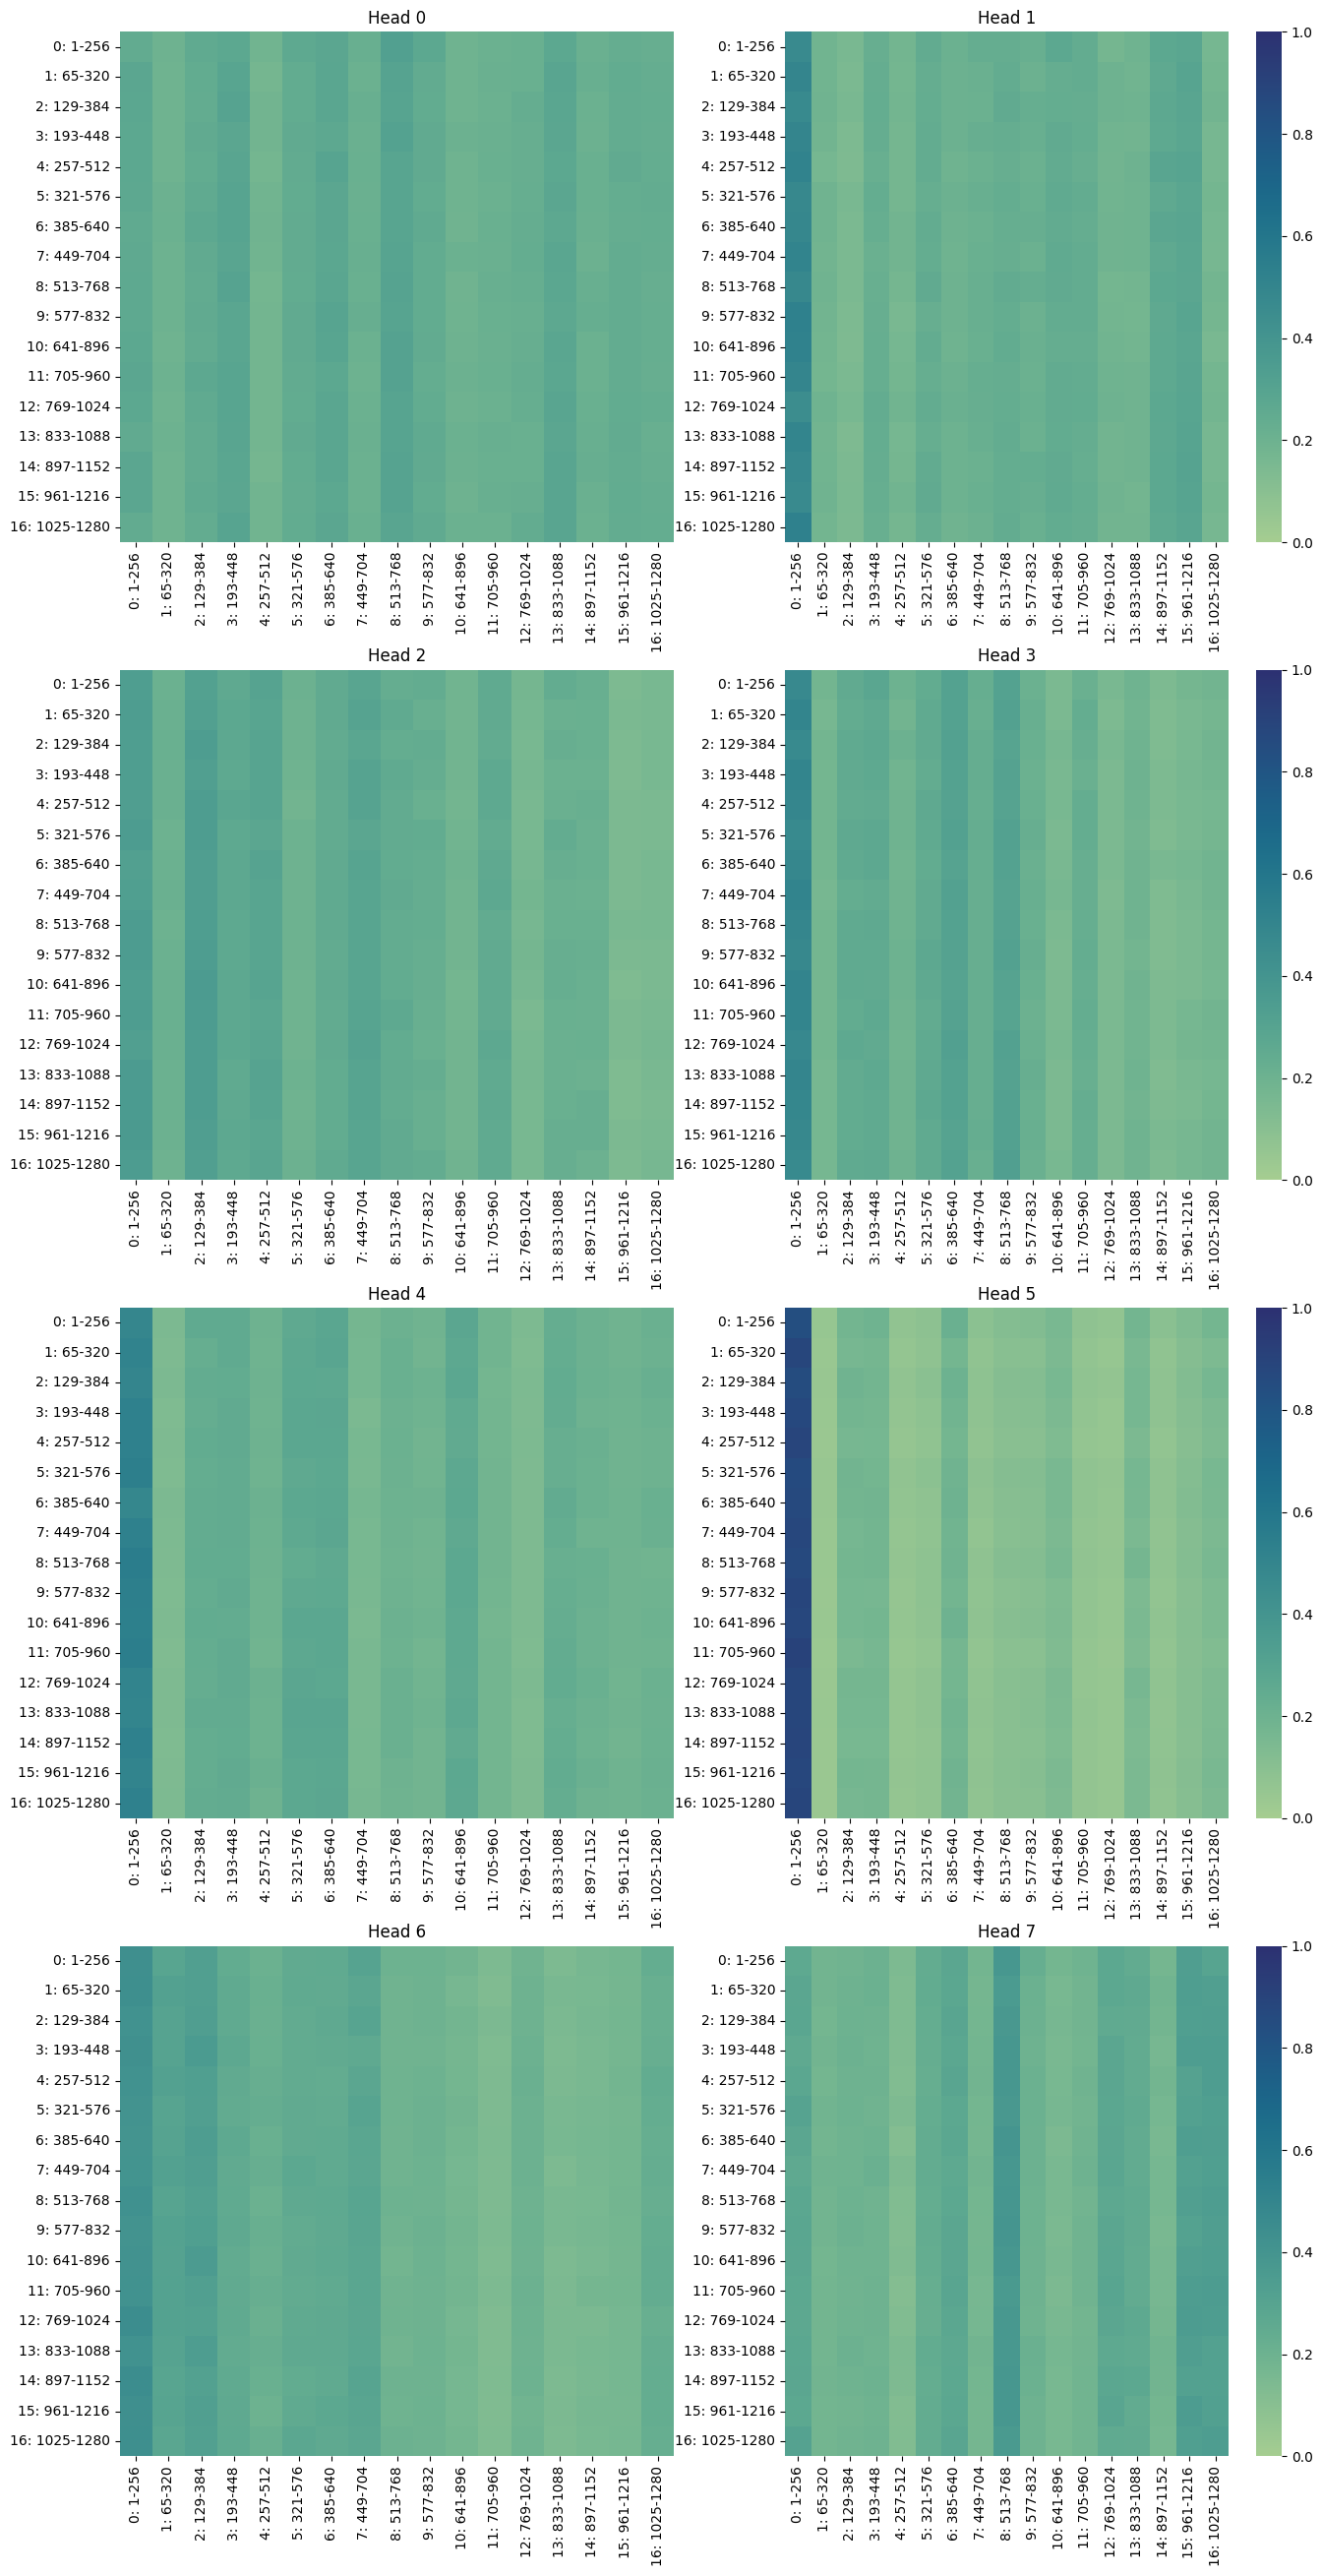

In [55]:
fig, axs = plt.subplots(4, 2, figsize=(16, 32), sharex=False, sharey=False)
axs = axs.flatten()
for i in range(8):
    ax = axs[i]
    plot_df = pd.DataFrame(normalize(attn[i], p=2, dim=1).detach().cpu().numpy()).rename(columns=pos_mapping, index=pos_mapping)
    sns.heatmap(plot_df, cmap="crest", ax=ax, vmin=0, vmax=1, cbar=i%2==1)
    ax.set_title(f"Head {i}")
plt.subplots_adjust(wspace=0.2)
plt.subplots_adjust(hspace=0.25)
plt.savefig(os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/haven/interpretability_wiv04_segment_attn_all_heads.pdf"), dpi=1024, bbox_inches="tight")

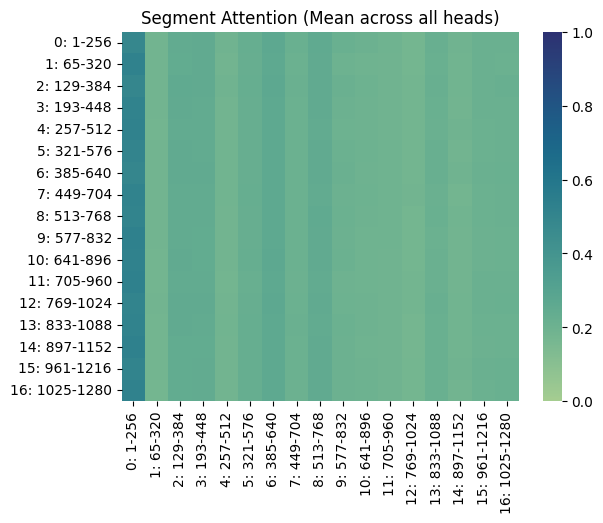

In [59]:
plot_df = pd.DataFrame(normalize(attn.mean(dim=0), p=2, dim=1).detach().cpu().numpy()).rename(columns=pos_mapping, index=pos_mapping)
ax = sns.heatmap(plot_df, cmap="crest", vmin=0, vmax=1)
ax.set_title(f"Segment Attention (Mean across all heads)")
plt.savefig(os.path.join(os.getcwd(), "..","..", "..", "..", "output/visualization/haven/interpretability_wiv04_segment_attn_heads_agg.pdf"), dpi=1024, bbox_inches="tight")

In [61]:
segments_attn = haven_model.self_attn.self_attn[idx, :, :, :]
segments_attn.shape

torch.Size([8, 17, 17])

In [98]:
enc_pos_attn_values = []
for enc_layer in range(6):
    for i in range(1273):
        pos = i
        pos_attn_values = []
        # traverse the pos_segment map
        for segment_idx, segment in pos_mapping_range.items():
            if i >= segment[0] and i < segment[1]:
                pos_idx_in_seg = i - segment[0]
                #print(f"i={i} in segment = {segment_idx}:{segment} with index {pos_idx_in_seg}")
                segment_attn_val = normalize(segments_attn.mean(dim=0).mean(dim=0), p=2, dim=0)[segment_idx].item()
                
                segment_attn_matrix=haven_model.pre_trained_model.encoder.layers[enc_layer].self_attn.self_attn[segment_idx]
                pos_attn_val = normalize(segment_attn_matrix.mean(dim=0).mean(dim=0), p=2, dim=0)[pos_idx_in_seg+1].item() # +1 to account for CLS token
                pos_attn_values.append(segment_attn_val*pos_attn_val)
        enc_pos_attn_values.append({
            "pos": pos+1,
            "enc_layer": enc_layer,
            "computed_attn_val": statistics.mean(pos_attn_values)
        })

In [99]:
enc_pos_attn_values_df = pd.DataFrame(enc_pos_attn_values)
enc_pos_attn_values_df["pos"] = enc_pos_attn_values_df["pos"].apply(str)

(1273, 3)
(1273, 3)
(1273, 3)
(1273, 3)
(1273, 3)
(1273, 3)


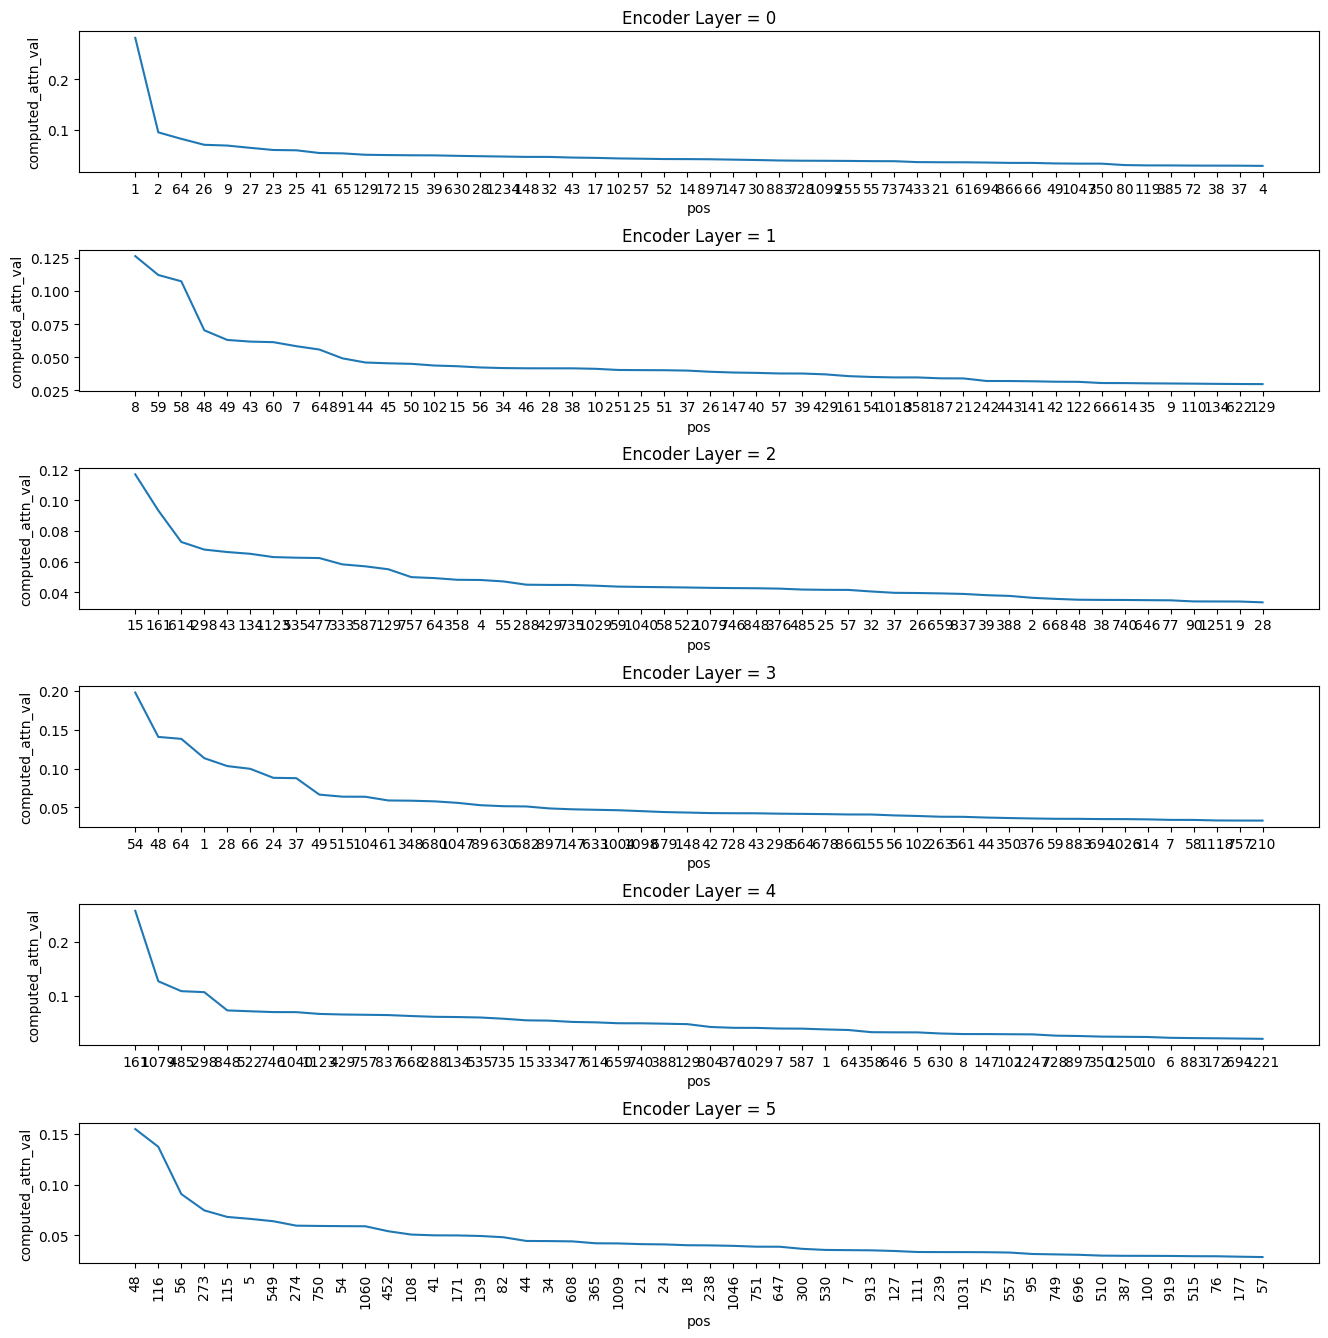

In [103]:
fig, axs = plt.subplots(6, 1, figsize=(16, 16), sharex=False, sharey=False)
axs = axs.flatten()
for enc_layer in range(6):
    ax = axs[enc_layer]
    enc_df = enc_pos_attn_values_df[enc_pos_attn_values_df["enc_layer"] == enc_layer].sort_values("computed_attn_val", ascending=False)
    print(enc_df.shape)
    sns.lineplot(data = enc_df[:50], x="pos", y="computed_attn_val", ax=ax)
    plt.xticks(rotation=90)
    ax.set_title(f"Encoder Layer = {enc_layer}")
plt.subplots_adjust(wspace=0.2)
plt.subplots_adjust(hspace=0.55)
    #sns.lineplot(enc_df["computed_attn_val"].values, ax=ax)

In [72]:
enc_df.sort_values("computed_attn_val", ascending=False)["pos"].values

array([  48,  116,   56, ..., 1271, 1272, 1273])